In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings("ignore")
import scipy.stats as stats
from scipy.stats import shapiro, kstest



pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [2]:
#CATEGORIES: 

columns_personal =      ['employee_number', 
                        'gender', 
                        'birth_year', 
                        'age', 
                        'marital_status',
                        'dist_home']

columns_job =           ['job_title',
                        'department',
                        'departured',
                        'year_at_comp',
                        'standard_hours',
                        'remote',
                        'business_travel',
                        'over_time', 
                        'job_level', 
                        'stock_opt_level', 
                        'traning_times_last_year', 
                        'perf_rate',
                        'year_last_promotion',
                        'year_current_mngr']

columns_education =     ['education_field',
                        'education_scale']


columns_income =        ['annual_salary',
                        'monthly_income',
                        'daily_rate',
                        'perc_salary_hike']

columns_satisfaction =  ['env_sat_rate',
                        'job_involvement',
                        'job_sat_rate',
                        'relationship_sat_rate',
                        'work_life_balance']

columns_emp_bgd =       ['num_comp_worked',
                        'tot_working_year']

In [3]:
df = pd.read_csv('../files/hr_raw_data_v2.csv')

In [4]:
df.head(1)

,employee_number,gender,birth_year,age,marital_status,dist_home,job_title,department,departured,year_at_comp,standard_hours,remote,business_travel,over_time,job_level,stock_opt_level,traning_times_last_year,perf_rate,year_last_promotion,year_current_mngr,education_field,education_scale,annual_salary,monthly_income,daily_rate,perc_salary_hike,env_sat_rate,job_involvement,job_sat_rate,relationship_sat_rate,work_life_balance,num_comp_worked,tot_working_year
0,1,M,1972,51.0,Unknown,6,Research Director,Research & Development,No,20,Full Time,Yes,Unknown,No,5,0,5,3.0,15,15,Unknown,3,195370.0,16280.83,2015.722222,13,1,3,3,3,3.0,7,NaN


## 1. DATA ANALYSYS - statistics

- Data analysis general
- Data analysis by category

### 1.2 DATA ANALYSIS BY CATEGORY

In [5]:
# DATA ANALYSIS BY CATEGORY

def data_analysis (dataframe, columns):

    print('📌CATEGORY ANALYSIS:\n')
    display(df[columns].describe().T)
    print('\n')

    for col in columns:
        
        print(f'📌Columna: {col.upper()} \n')
        print('Null counter:', dataframe[col].isna().sum(), '\n')
        print('These are the unique values:', dataframe[col].unique(),'\n')
        print('These are values counter:', dataframe[col].value_counts(dropna=False),'\n')
        print('-------------')

#### 1.2.1 Personal Columns

In [6]:
data_analysis(df, columns_personal)

📌CATEGORY ANALYSIS:



,count,mean,std,min,25%,50%,75%,max
employee_number,1614.0,807.500000,466.065982,1.0,404.25,807.5,1210.75,1614.0
birth_year,1614.0,1986.076208,9.101332,1963.0,1980.00,1987.0,1993.00,2005.0
age,1614.0,36.923792,9.101332,18.0,30.00,36.0,43.00,60.0
dist_home,1614.0,11.141884,10.450560,1.0,2.00,8.0,17.00,49.0




📌Columna: EMPLOYEE_NUMBER 

Null counter: 0 

These are the unique values: [   1    2    3 ... 1612 1613 1614] 

These are values counter: employee_number
1614    1
1       1
2       1
3       1
4       1
5       1
6       1
7       1
8       1
9       1
10      1
11      1
12      1
13      1
1598    1
1597    1
1596    1
1595    1
1594    1
1593    1
1592    1
1591    1
1590    1
1589    1
1588    1
1587    1
1586    1
1585    1
1584    1
1583    1
46      1
45      1
44      1
43      1
42      1
41      1
40      1
39      1
38      1
37      1
36      1
35      1
34      1
33      1
32      1
31      1
62      1
61      1
60      1
59      1
58      1
57      1
56      1
55      1
54      1
53      1
52      1
51      1
50      1
49      1
48      1
47      1
78      1
77      1
76      1
75      1
74      1
73      1
72      1
71      1
70      1
69      1
68      1
67      1
66      1
65      1
64      1
63      1
94      1
93      1
92      1
91      1
90      1
89      1
88 

#### 1.2.2 Job Columns

In [7]:
data_analysis(df, columns_job)

📌CATEGORY ANALYSIS:



,count,mean,std,min,25%,50%,75%,max
year_at_comp,1614.0,7.132590,6.124237,0.0,3.0,5.0,9.0,40.0
job_level,1614.0,2.068154,1.101344,1.0,1.0,2.0,3.0,5.0
stock_opt_level,1614.0,0.791202,0.842396,0.0,0.0,1.0,1.0,3.0
traning_times_last_year,1614.0,2.809789,1.297765,0.0,2.0,3.0,3.0,6.0
perf_rate,1419.0,3.150810,0.357990,3.0,3.0,3.0,3.0,4.0
year_last_promotion,1614.0,2.245973,3.235665,0.0,0.0,1.0,3.0,15.0
year_current_mngr,1614.0,4.220570,3.562695,0.0,2.0,3.0,7.0,17.0




📌Columna: JOB_TITLE 

Null counter: 0 

These are the unique values: ['Research Director' 'Manager' 'Sales Executive' 'Manufacturing Director'
 'Research Scientist' 'Healthcare Representative' 'Laboratory Technician'
 'Sales Representative' 'Human Resources'] 

These are values counter: job_title
Sales Executive              369
Research Scientist           314
Laboratory Technician        278
Manufacturing Director       158
Healthcare Representative    149
Manager                      111
Sales Representative          90
Research Director             88
Human Resources               57
Name: count, dtype: int64 

-------------
📌Columna: DEPARTMENT 

Null counter: 0 

These are the unique values: ['Research & Development' 'Unknown' 'Sales' 'Human Resources'] 

These are values counter: department
Research & Development    1001
Sales                      464
Unknown                     91
Human Resources             58
Name: count, dtype: int64 

-------------
📌Columna: DEPARTURED 



#### 1.2.3 Income Columns

In [8]:
data_analysis(df, columns_income)

📌CATEGORY ANALYSIS:



,count,mean,std,min,25%,50%,75%,max
annual_salary,1614.0,64908.336671,45788.528503,10090.000000,28111.13000,53914.110000,93755.000000,199990.000000
monthly_income,1614.0,5701.477487,5809.786253,1000.000000,2342.59000,4492.840000,8055.830000,94083.000000
daily_rate,1614.0,669.630678,472.353332,104.103175,290.03551,556.256661,967.313492,2063.388889
perc_salary_hike,1614.0,15.165428,3.648610,11.000000,12.00000,14.000000,18.000000,25.000000




📌Columna: ANNUAL_SALARY 

Null counter: 0 

These are the unique values: [195370.         199990.         192320.         171690.
 153407.07       171503.33333333 100071.84        53914.11
 165950.         191324.62       199730.         134020.
 132060.         195450.         180410.         192460.
  53914.11       107480.         167520.          62010.
 198450.          40010.         104470.         160640.
  32100.         102660.         104750.          61620.
  47210.          28111.13        46150.         169590.
 103720.          54060.          59020.         108550.
  59140.          66460.         139730.         133163.33333333
  66870.          47350.         138720.         190450.
 160236.66666667  96130.         115100.          43076.66666667
 170460.          50653.33333333  36920.         198470.
  23080.          57470.         104220.          63470.
  23480.          30720.         124900.          80200.
 170680.          89430.         192720.          55

#### 1.2.4 Education Columns

In [9]:
data_analysis(df,columns_education)

📌CATEGORY ANALYSIS:



,count,mean,std,min,25%,50%,75%,max
education_scale,1614.0,2.925031,1.022357,1.0,2.0,3.0,4.0,5.0




📌Columna: EDUCATION_FIELD 

Null counter: 0 

These are the unique values: ['Unknown' 'Life Sciences' 'Technical Degree' 'Medical' 'Other'
 'Marketing' 'Human Resources'] 

These are values counter: education_field
Unknown             745
Life Sciences       349
Medical             276
Marketing           104
Technical Degree     69
Other                59
Human Resources      12
Name: count, dtype: int64 

-------------
📌Columna: EDUCATION_SCALE 

Null counter: 0 

These are the unique values: [3 4 2 1 5] 

These are values counter: education_scale
3    621
4    445
2    314
1    180
5     54
Name: count, dtype: int64 

-------------


#### 1.2.4 Satisfaction Columns

In [10]:
data_analysis(df,columns_satisfaction)

📌CATEGORY ANALYSIS:



,count,mean,std,min,25%,50%,75%,max
env_sat_rate,1614.0,4.294919,6.993559,1.0,2.0,3.0,4.0,49.0
job_involvement,1614.0,2.739777,0.711567,1.0,2.0,3.0,3.0,4.0
job_sat_rate,1614.0,2.738538,1.106163,1.0,2.0,3.0,4.0,4.0
relationship_sat_rate,1614.0,2.704461,1.079031,1.0,2.0,3.0,4.0,4.0
work_life_balance,1506.0,2.759628,0.702622,1.0,2.0,3.0,3.0,4.0




📌Columna: ENV_SAT_RATE 

Null counter: 0 

These are the unique values: [ 1  3  4  2 42 37 35 25 27 31 39 21 15 14 33 19 12 13 28 47 36 29 24 46
 16 22 41 49 11 48 18 10 45 38 17 20 26 43] 

These are values counter: env_sat_rate
4     460
3     459
1     298
2     297
12      7
35      6
13      6
24      5
47      5
14      5
41      4
42      4
46      4
36      4
48      4
20      3
22      3
11      3
18      3
45      3
27      3
25      3
17      3
37      2
38      2
16      2
31      2
15      2
19      2
29      2
28      1
33      1
21      1
39      1
49      1
10      1
26      1
43      1
Name: count, dtype: int64 

-------------
📌Columna: JOB_INVOLVEMENT 

Null counter: 0 

These are the unique values: [3 2 4 1] 

These are values counter: job_involvement
3    955
2    406
4    164
1     89
Name: count, dtype: int64 

-------------
📌Columna: JOB_SAT_RATE 

Null counter: 0 

These are the unique values: [3 4 1 2] 

These are values counter: job_sat_rate
4    514
3    48

#### 1.2.5 Employement Background Columns

In [11]:
data_analysis(df, columns_emp_bgd)

📌CATEGORY ANALYSIS:



,count,mean,std,min,25%,50%,75%,max
num_comp_worked,1614.0,2.673482,2.506152,0.0,1.0,2.0,4.0,9.0
tot_working_year,1088.0,11.318934,7.727675,0.0,6.0,10.0,15.0,40.0




📌Columna: NUM_COMP_WORKED 

Null counter: 0 

These are the unique values: [7 0 1 3 2 4 8 9 5 6] 

These are values counter: num_comp_worked
1    573
0    226
3    169
4    157
2    156
7     84
6     73
5     66
9     59
8     51
Name: count, dtype: int64 

-------------
📌Columna: TOT_WORKING_YEAR 

Null counter: 526 

These are the unique values: [nan 34. 22. 28. 20. 21. 33. 40. 18. 25. 15. 17. 26. 16. 24. 14. 23. 27.
 19. 11. 38. 37. 13. 12. 29. 10. 36. 35.  9. 31. 32.  8.  7. 30.  6.  5.
  4.  3.  2.  1.  0.] 

These are values counter: tot_working_year
NaN     526
10.0    144
8.0      86
6.0      84
9.0      69
5.0      66
7.0      56
4.0      54
1.0      53
12.0     34
3.0      32
13.0     30
14.0     30
11.0     29
16.0     28
15.0     28
20.0     28
18.0     27
21.0     23
17.0     22
2.0      21
22.0     18
19.0     17
24.0     14
28.0     13
23.0     13
0.0       8
26.0      8
33.0      6
36.0      6
29.0      6
25.0      6
27.0      5
37.0      5
31.0      4
32.0      3
40

In [12]:
#Vamos a poner la misma escala a las siguientes columnas:
df['env_sat_rate_scale'] = pd.cut(df['env_sat_rate'],bins = 4, labels= ['Low', 'Medium-Low','Medium-High', 'High'])

In [13]:
df['env_sat_rate_scale_num'] = pd.cut(df['env_sat_rate'],bins = 4, labels= ['1', '2','3', '4'])

In [14]:
to_int = ['job_involvement', 'job_sat_rate', 'relationship_sat_rate', 'work_life_balance', 'env_sat_rate_scale_num']

def convert_int (data, list_columns):
    
        for col in list_columns:   
            try: 
                data[col] = data[col].str.replace(',','.')
                data[col] = pd.to_numeric(data[col], errors='coerce').astype('Int64')

            except:  data[col] = pd.to_numeric(data[col], errors='coerce').astype('Int64')

In [15]:
convert_int(df,to_int)

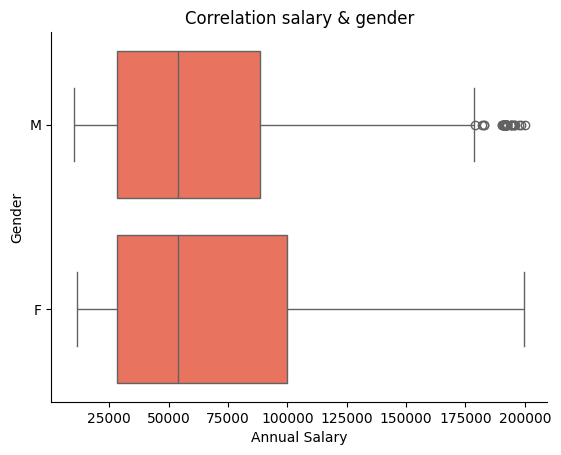

In [16]:
sns.boxplot(data=df, y='gender', x='annual_salary', color = 'tomato')
plt.title('Correlation salary & gender')
plt.xlabel('Annual Salary')
plt.ylabel('Gender')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False);

Interpretación: El rango salarial de las mujeres es un poco mayor que el de los hombres, aunque solo hay outliers en los salarios de los hombres. La mediana es igual es ambos géneros.

In [17]:
df['standard_hours'].mode()

0    Part Time
Name: standard_hours, dtype: object

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1614 entries, 0 to 1613
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   employee_number          1614 non-null   int64   
 1   gender                   1614 non-null   object  
 2   birth_year               1614 non-null   int64   
 3   age                      1614 non-null   float64 
 4   marital_status           1614 non-null   object  
 5   dist_home                1614 non-null   int64   
 6   job_title                1614 non-null   object  
 7   department               1614 non-null   object  
 8   departured               1614 non-null   object  
 9   year_at_comp             1614 non-null   int64   
 10  standard_hours           1276 non-null   object  
 11  remote                   1614 non-null   object  
 12  business_travel          1614 non-null   object  
 13  over_time                1614 non-null   object  
 14  job_leve

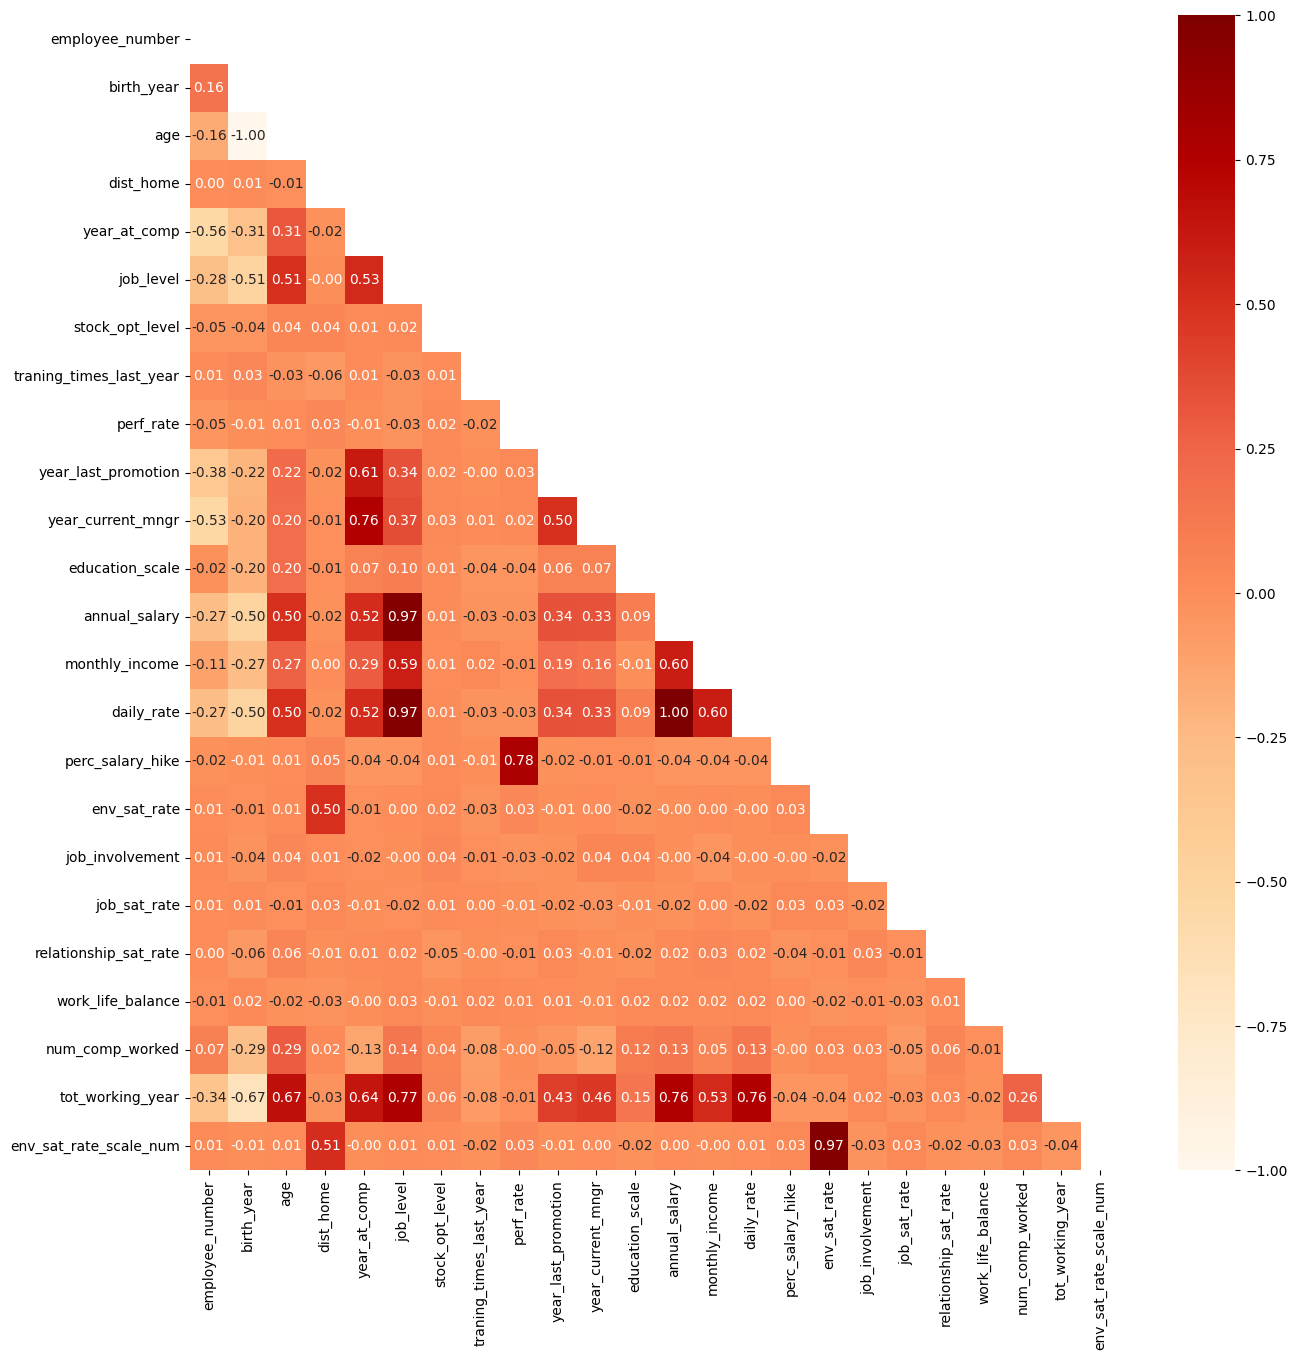

In [19]:
# GENERAL DATA ANALYSIS

numerics = df.select_dtypes(include = np.number).columns
df_corr = df[numerics].corr(method = 'pearson')


plt.figure(figsize = (15, 15))

mask = np.triu(np.ones_like(df_corr, dtype=bool))

sns.heatmap(df_corr, 
            annot = True, 
            fmt = ".2f", 
            cmap = "OrRd", 
            vmax = 1, 
            vmin = -1, 
            mask = mask); 

In [20]:
df.isnull().sum() / df.shape[0] * 100

employee_number             0.000000
gender                      0.000000
birth_year                  0.000000
age                         0.000000
marital_status              0.000000
dist_home                   0.000000
job_title                   0.000000
department                  0.000000
departured                  0.000000
year_at_comp                0.000000
standard_hours             20.941760
remote                      0.000000
business_travel             0.000000
over_time                   0.000000
job_level                   0.000000
stock_opt_level             0.000000
traning_times_last_year     0.000000
perf_rate                  12.081784
year_last_promotion         0.000000
year_current_mngr           0.000000
education_field             0.000000
education_scale             0.000000
annual_salary               0.000000
monthly_income              0.000000
daily_rate                  0.000000
perc_salary_hike            0.000000
env_sat_rate                0.000000
j

In [21]:
df_estadisticos_num = df.select_dtypes(include = np.number).describe().T

In [22]:
df_estadisticos_num

,count,mean,std,min,25%,50%,75%,max
employee_number,1614.0,807.5,466.065982,1.0,404.25,807.5,1210.75,1614.0
birth_year,1614.0,1986.076208,9.101332,1963.0,1980.0,1987.0,1993.0,2005.0
age,1614.0,36.923792,9.101332,18.0,30.0,36.0,43.0,60.0
dist_home,1614.0,11.141884,10.45056,1.0,2.0,8.0,17.0,49.0
year_at_comp,1614.0,7.13259,6.124237,0.0,3.0,5.0,9.0,40.0
job_level,1614.0,2.068154,1.101344,1.0,1.0,2.0,3.0,5.0
stock_opt_level,1614.0,0.791202,0.842396,0.0,0.0,1.0,1.0,3.0
traning_times_last_year,1614.0,2.809789,1.297765,0.0,2.0,3.0,3.0,6.0
perf_rate,1419.0,3.15081,0.35799,3.0,3.0,3.0,3.0,4.0
year_last_promotion,1614.0,2.245973,3.235665,0.0,0.0,1.0,3.0,15.0


In [23]:
df_estadisticos_cat = df.select_dtypes(exclude = np.number).describe().T

In [24]:
df_estadisticos_cat['freq%'] = df_estadisticos_cat['freq'].values/df.shape[0]*100

In [25]:
df_estadisticos_cat

,count,unique,top,freq,freq%
gender,1614,2,M,971,60.16109
marital_status,1614,4,Unknown,651,40.334572
job_title,1614,9,Sales Executive,369,22.862454
department,1614,4,Research & Development,1001,62.019827
departured,1614,2,No,1355,83.952912
standard_hours,1276,2,Part Time,888,55.018587
remote,1614,2,Yes,1000,61.957869
business_travel,1614,4,Unknown,772,47.831475
over_time,1614,3,No,682,42.255266
education_field,1614,7,Unknown,745,46.158612


In [26]:
df['salary_scale'] = pd.cut(df['annual_salary'],bins = 3, labels= ['Low', 'Medium', 'High']) 

In [27]:
# filtramos los datos para obtener los grupos. Estos grupos van a ser series de datos
grupo_research = df[df['department'] == 'Research & Development'] [['employee_number', 'gender', 'birth_year', 'age', 'marital_status',
       'dist_home', 'job_title', 'departured', 'year_at_comp',
       'standard_hours', 'remote', 'business_travel', 'over_time', 'job_level',
       'stock_opt_level', 'traning_times_last_year', 'perf_rate',
       'year_last_promotion', 'year_current_mngr', 'education_field',
       'education_scale', 'annual_salary', 'monthly_income', 'daily_rate',
       'perc_salary_hike', 'env_sat_rate', 'job_involvement', 'job_sat_rate',
       'relationship_sat_rate', 'work_life_balance', 'num_comp_worked',
       'tot_working_year', 'env_sat_rate_scale']]
grupo_unknown = df[df['department'] == 'Unknown'] [['employee_number', 'gender', 'birth_year', 'age', 'marital_status',
       'dist_home', 'job_title', 'departured', 'year_at_comp',
       'standard_hours', 'remote', 'business_travel', 'over_time', 'job_level',
       'stock_opt_level', 'traning_times_last_year', 'perf_rate',
       'year_last_promotion', 'year_current_mngr', 'education_field',
       'education_scale', 'annual_salary', 'monthly_income', 'daily_rate',
       'perc_salary_hike', 'env_sat_rate', 'job_involvement', 'job_sat_rate',
       'relationship_sat_rate', 'work_life_balance', 'num_comp_worked',
       'tot_working_year', 'env_sat_rate_scale']]
grupo_sales = df[df['department'] == 'Sales'] [['employee_number', 'gender', 'birth_year', 'age', 'marital_status',
       'dist_home', 'job_title', 'departured', 'year_at_comp',
       'standard_hours', 'remote', 'business_travel', 'over_time', 'job_level',
       'stock_opt_level', 'traning_times_last_year', 'perf_rate',
       'year_last_promotion', 'year_current_mngr', 'education_field',
       'education_scale', 'annual_salary', 'monthly_income', 'daily_rate',
       'perc_salary_hike', 'env_sat_rate', 'job_involvement', 'job_sat_rate',
       'relationship_sat_rate', 'work_life_balance', 'num_comp_worked',
       'tot_working_year', 'env_sat_rate_scale']]
grupo_hhrr = df[df['department'] == 'Human Resources'] [['employee_number', 'gender', 'birth_year', 'age', 'marital_status',
       'dist_home', 'job_title', 'departured', 'year_at_comp',
       'standard_hours', 'remote', 'business_travel', 'over_time', 'job_level',
       'stock_opt_level', 'traning_times_last_year', 'perf_rate',
       'year_last_promotion', 'year_current_mngr', 'education_field',
       'education_scale', 'annual_salary', 'monthly_income', 'daily_rate',
       'perc_salary_hike', 'env_sat_rate', 'job_involvement', 'job_sat_rate',
       'relationship_sat_rate', 'work_life_balance', 'num_comp_worked',
       'tot_working_year', 'env_sat_rate_scale']]

In [28]:
lista = ['Research & Development', 'Unknown', 'Sales', 'Human Resources']

In [29]:
lista1 = ['Part Time', 'Full Time']

In [30]:
df_grupo_research = pd.DataFrame(grupo_research)
df_grupo_unknown = pd.DataFrame(grupo_unknown)
df_grupo_sales = pd.DataFrame(grupo_sales)
df_grupo_hhrr = pd.DataFrame(grupo_hhrr)

In [31]:
#imprimimos las estadísticas:
for filtro in lista:
    print(filtro)
    display(df[df['department'] == filtro]['annual_salary'].describe().round(2).reset_index().T)
    print('-' * 40)

Research & Development


,0,1,2,3,4,5,6,7
index,count,mean,std,min,25%,50%,75%,max
annual_salary,1001.0,58414.13,43038.75,10090.0,28111.13,44220.0,64720.0,199730.0


----------------------------------------
Unknown


,0,1,2,3,4,5,6,7
index,count,mean,std,min,25%,50%,75%,max
annual_salary,91.0,167680.14,27964.12,100071.84,153407.07,170990.0,191324.62,199990.0


----------------------------------------
Sales


,0,1,2,3,4,5,6,7
index,count,mean,std,min,25%,50%,75%,max
annual_salary,464.0,61231.4,28763.74,10520.0,48387.5,53914.11,69690.0,187890.0


----------------------------------------
Human Resources


,0,1,2,3,4,5,6,7
index,count,mean,std,min,25%,50%,75%,max
annual_salary,58.0,45159.34,27708.86,20640.0,28111.13,28111.13,53914.11,153407.07


----------------------------------------


''

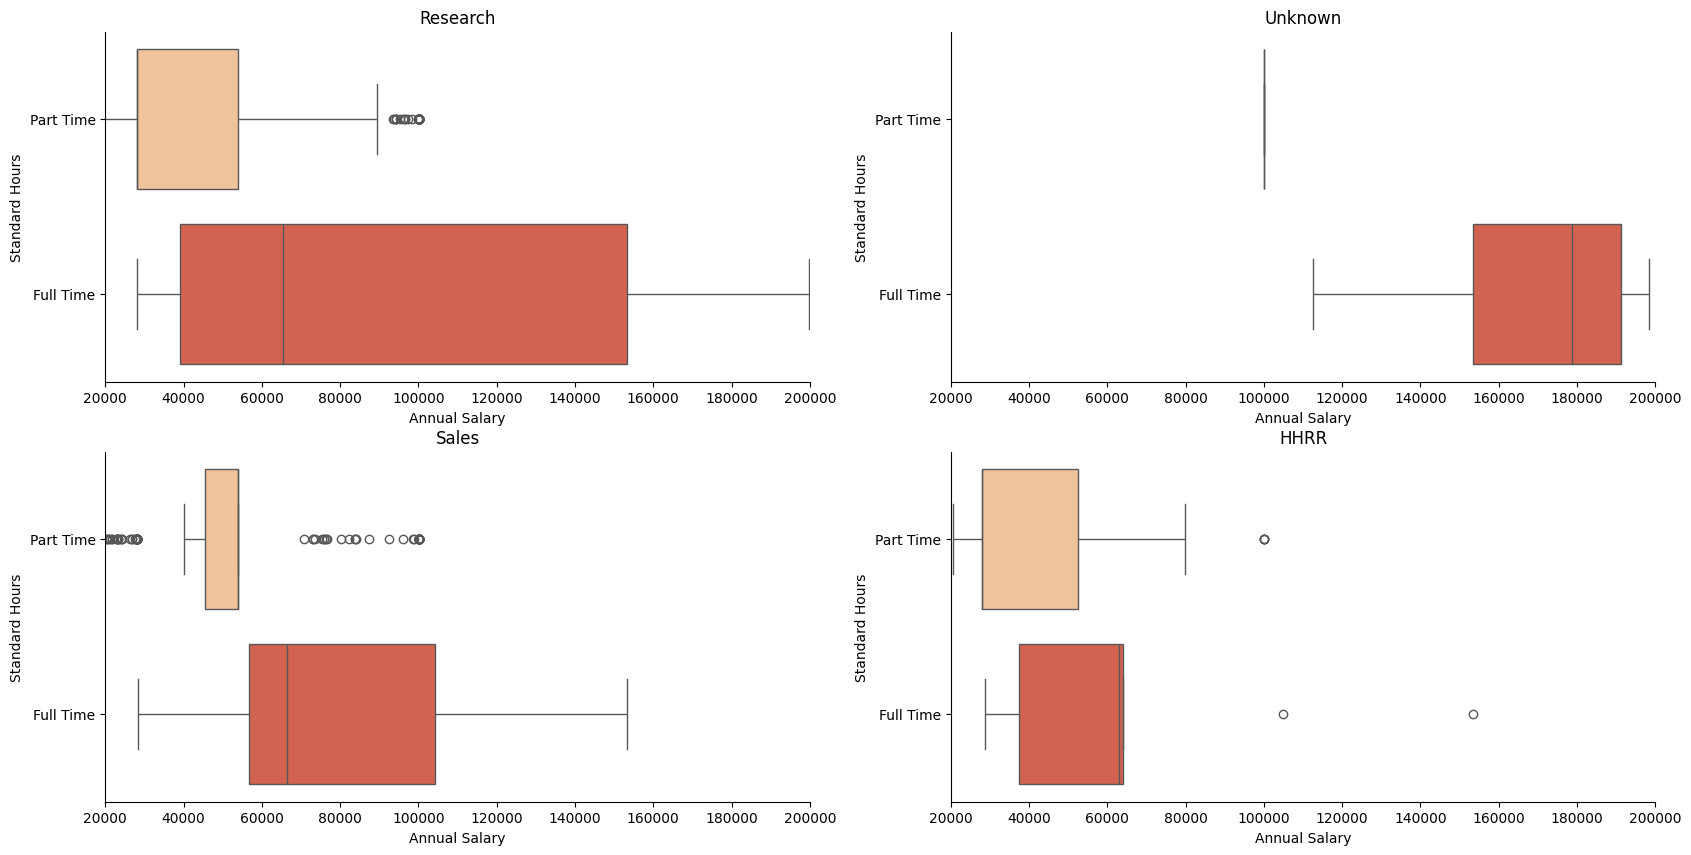

In [32]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (20, 10))
sns.boxplot(x = "annual_salary",
            y = "standard_hours",
            order = lista1,
            data = df_grupo_research,
            palette = "OrRd",
            ax = axes[0,0])
axes[0,0].set_title("Research")
axes[0,0].set_xlabel("Annual Salary")
axes[0,0].set_ylabel("Standard Hours")
axes[0,0].spines['right'].set_visible(False)
axes[0,0].spines['top'].set_visible(False)

sns.boxplot(x = "annual_salary",
            y = "standard_hours",
            order = lista1,
            data = df_grupo_unknown,
            palette = "OrRd",
            ax = axes[0,1])
axes[0,1].set_title("Unknown")
axes[0,1].set_xlabel("Annual Salary")
axes[0,1].set_ylabel("Standard Hours")
axes[0,1].spines['right'].set_visible(False)
axes[0,1].spines['top'].set_visible(False)

sns.boxplot(x = "annual_salary",
            y = "standard_hours",
            order = lista1,
            data = df_grupo_sales,
            palette = "OrRd",
            ax = axes[1,0])
axes[1,0].set_title("Sales")
axes[1,0].set_xlabel("Annual Salary")
axes[1,0].set_ylabel("Standard Hours")
axes[1,0].spines['right'].set_visible(False)
axes[1,0].spines['top'].set_visible(False)

sns.boxplot(x = "annual_salary",
            y = "standard_hours",
            order = lista1,
            data = df_grupo_hhrr,
            palette = "OrRd",
            ax = axes[1,1])
axes[1,1].set_title("HHRR")
axes[1,1].set_xlabel("Annual Salary")
axes[1,1].set_ylabel("Standard Hours")
axes[1,1].spines['right'].set_visible(False)
axes[1,1].spines['top'].set_visible(False)

#ponemos la misma escala en los ejes:
#eje x:
axes[0,0].set_xlim(20000,200000) 
axes[0,1].set_xlim(20000,200000) 
axes[1,0].set_xlim(20000,200000) 
axes[1,1].set_xlim(20000,200000);
;

Interpretación: Este gráfico compara los salarios anuales y los tipos de jornada (jornada completa y media jornada) en los diferentes departamentos (Research, Sales, HRRR y Unknown). 
Además, hay variaciones significativas entre departamentos, destacando Research con los salarios más altos y un mayor número de outilers en los empleados de media jornada, junto con Sales.

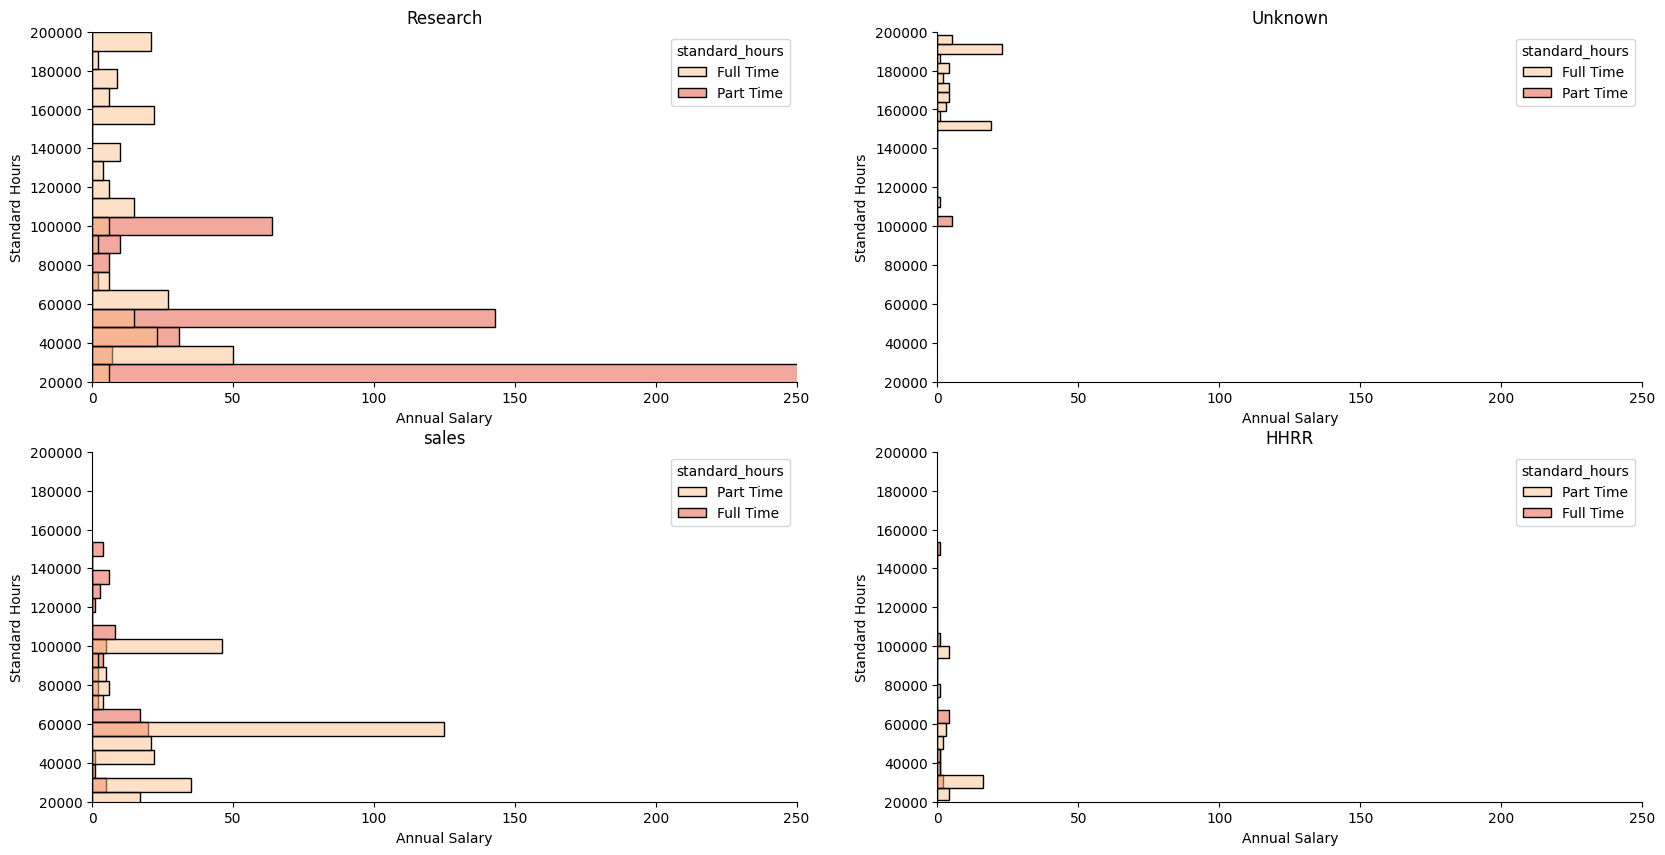

In [33]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (20, 10))

sns.histplot(y = "annual_salary",
            hue = "standard_hours", 
            data = df_grupo_research, 
            palette = "OrRd", 
            bins = 20, 
            ax = axes[0,0])
axes[0,0].set_title("Research")
axes[0,0].set_xlabel("Annual Salary")
axes[0,0].set_ylabel("Standard Hours")
axes[0,0].spines['right'].set_visible(False)
axes[0,0].spines['top'].set_visible(False)

sns.histplot(y = "annual_salary",
            hue = "standard_hours",  
            data = df_grupo_unknown, 
            palette = "OrRd", 
            bins = 20, 
            ax = axes[0,1])
axes[0,1].set_title("Unknown")
axes[0,1].set_xlabel("Annual Salary")
axes[0,1].set_ylabel("Standard Hours")
axes[0,1].spines['right'].set_visible(False)
axes[0,1].spines['top'].set_visible(False)

sns.histplot(y = "annual_salary",
            hue = "standard_hours",  
            data = df_grupo_sales, 
            palette = "OrRd", 
            bins = 20, 
            ax = axes[1,0])
axes[1,0].set_title("sales")
axes[1,0].set_xlabel("Annual Salary")
axes[1,0].set_ylabel("Standard Hours")
axes[1,0].spines['right'].set_visible(False)
axes[1,0].spines['top'].set_visible(False)

sns.histplot(y = "annual_salary",
            hue = "standard_hours",  
            data = df_grupo_hhrr, 
            palette = "OrRd", 
            bins = 20, 
            ax = axes[1,1])
axes[1,1].set_title("HHRR")
axes[1,1].set_xlabel("Annual Salary")
axes[1,1].set_ylabel("Standard Hours")
axes[1,1].spines['right'].set_visible(False)
axes[1,1].spines['top'].set_visible(False)

#ponemos la misma escala en los ejes:
#eje x,:
axes[0,0].set_xlim(0,250) 
axes[0,1].set_xlim(0,250) 
axes[1,0].set_xlim(0,250) 
axes[1,1].set_xlim(0,250) 

#eje y:
axes[0,0].set_ylim(20000,200000) 
axes[0,1].set_ylim(20000,200000) 
axes[1,0].set_ylim(20000,200000) 
axes[1,1].set_ylim(20000,200000);

Este gráfico lo hemos utilizado para apoyar visualmente la interpretación de la gráfica anterior.

In [34]:
df['job_level'].unique()

array([5, 4, 3, 2, 1])

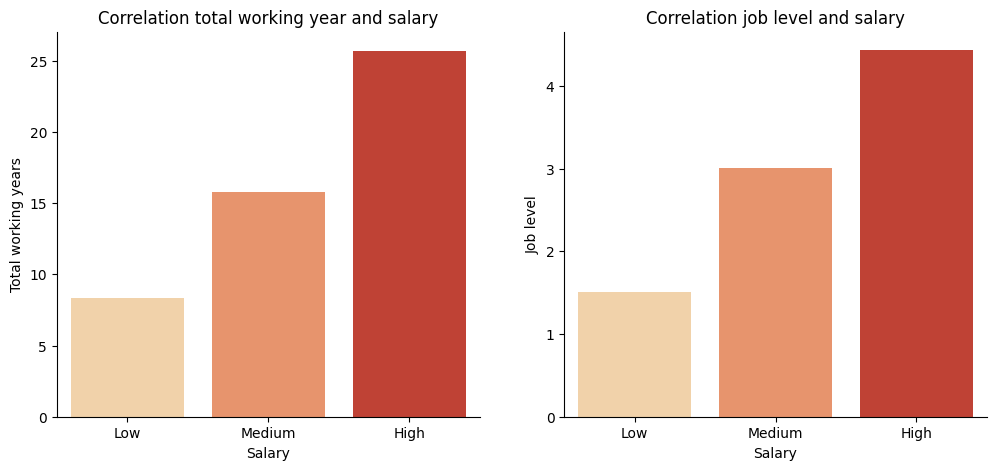

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

sns.barplot(data=df, y='tot_working_year', 
            x='salary_scale',
            palette='OrRd',
            ci=False,
            ax=axes[0])
axes[0].set_title("Correlation total working year and salary")
axes[0].set_xlabel("Salary")
axes[0].set_ylabel("Total working years")
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

sns.barplot(data=df, y='job_level', 
            x='salary_scale',
            palette='OrRd',
            ci=False)
axes[1].set_title("Correlation job level and salary")
axes[1].set_ylabel("Job level")
axes[1].set_xlabel("Salary")
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)
plt.show();


Interpretación: Como es de esperar los trabajadores con mayor antigüedad y una mayor categoría laboral tienen un salario mayor.

In [36]:
df['dist_home_scale'] = pd.cut(df['dist_home'],bins = 3, labels= ['Near', 'Medium', 'Far']) 

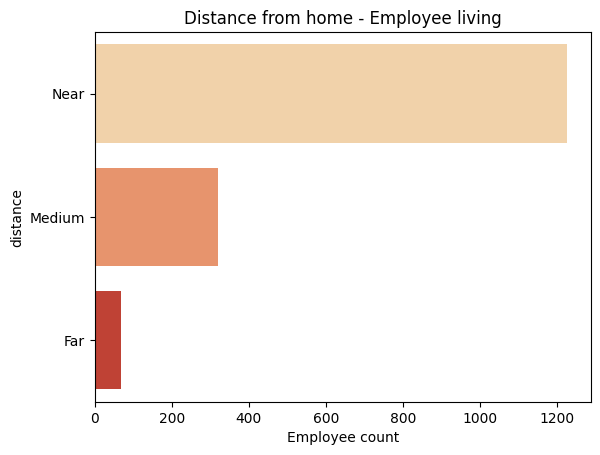

In [37]:
sns.countplot(data=df,
              y='dist_home_scale',
              palette='OrRd')
plt.title('Distance from home - Employee living')
plt.xlabel('Employee count')
plt.ylabel('distance');


Interpretación : la mayor parte de los empleados viven cerca.

In [38]:
df['env_sat_rate_scale'].unique()

['Low', 'High', 'Medium-High', 'Medium-Low']
Categories (4, object): ['Low' < 'Medium-Low' < 'Medium-High' < 'High']

In [39]:
df['env_sat_rate_scale_num'].unique()

<IntegerArray>
[1, 4, 3, 2]
Length: 4, dtype: Int64

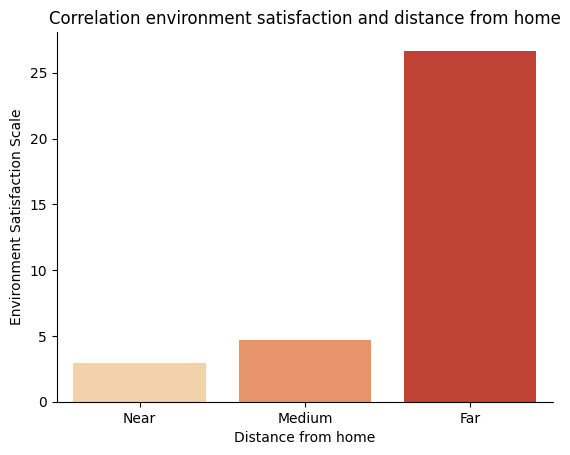

In [40]:
sns.barplot( x='dist_home_scale',y='env_sat_rate',
            data=df,
            palette= 'OrRd',
            ci=False)

plt.title("Correlation environment satisfaction and distance from home")
plt.ylabel("Environment Satisfaction Scale")
plt.xlabel("Distance from home")
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False);

Interpretación: Se aprecia una clara relación entre una mayor distancia del trabajo y una mayor satisfacción.
Este dato nos ha sorprendido, por lo que hemos decidido entrar a analizar en mayor profundidad otras variables que pueden influir en el grado de satisfacción de las personas que viven más lejos del trabajo. `A más lejanía del trabajo, más satisfecho`.

In [41]:
df['dist_home_scale'].unique()

['Near', 'Medium', 'Far']
Categories (3, object): ['Near' < 'Medium' < 'Far']

In [42]:
df['env_sat_rate_scale'].unique()

['Low', 'High', 'Medium-High', 'Medium-Low']
Categories (4, object): ['Low' < 'Medium-Low' < 'Medium-High' < 'High']

In [43]:
far_df = df[df['dist_home_scale'] == 'Far']

In [44]:
near_df = df[df['dist_home_scale'] == 'Near']

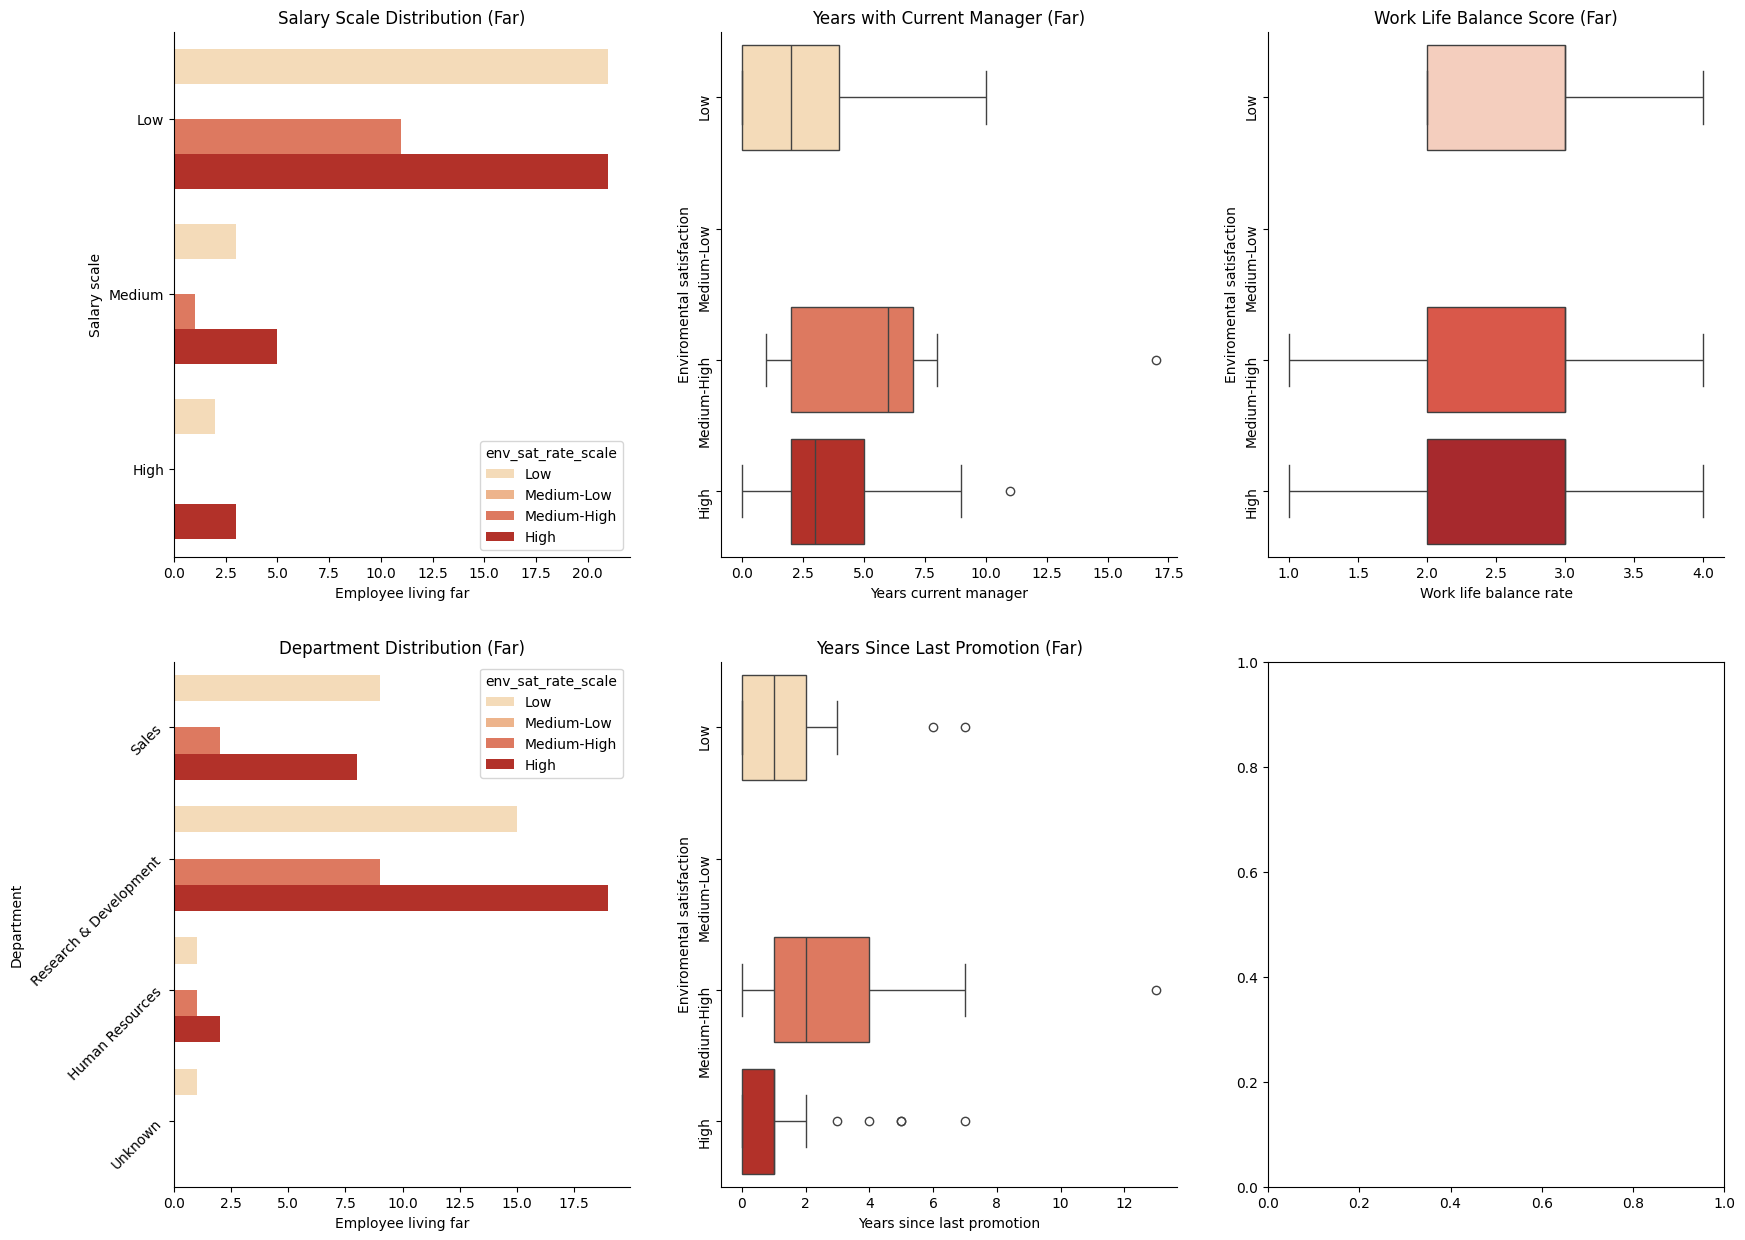

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(20, 15)) 

sns.countplot(data=far_df,
              y='salary_scale',
              hue='env_sat_rate_scale',
              ax=axes[0,0],
              palette='OrRd')
axes[0,0].set_title('Salary Scale Distribution (Far)')
axes[0,0].set_xlabel('Employee living far')
axes[0,0].set_ylabel('Salary scale')
axes[0,0].spines['right'].set_visible(False)
axes[0,0].spines['top'].set_visible(False)


sns.countplot(data=far_df,
              y='department',
              hue='env_sat_rate_scale',
              ax=axes[1,0],
              palette='OrRd')
axes[1,0].set_title('Department Distribution (Far)')
axes[1,0].tick_params(axis='y', rotation=45)
axes[1,0].set_xlabel('Employee living far')
axes[1,0].set_ylabel('Department')
axes[1,0].spines['right'].set_visible(False)
axes[1,0].spines['top'].set_visible(False)


sns.boxplot(data=far_df,
            x='year_current_mngr',
            ax=axes[0,1],
            y='env_sat_rate_scale',
            palette='OrRd')
axes[0,1].set_title('Years with Current Manager (Far)')
axes[0,1].tick_params(axis='y', rotation=45)
axes[0,1].set_xlabel('Years current manager')
axes[0,1].set_ylabel('Enviromental satisfaction')
axes[0,1].tick_params(axis='y', rotation=90)
axes[0,1].spines['right'].set_visible(False)
axes[0,1].spines['top'].set_visible(False)


sns.boxplot(data=far_df, x='year_last_promotion',
            y='env_sat_rate_scale',
            ax=axes[1,1],
            palette='OrRd')
axes[1,1].set_title('Years Since Last Promotion (Far)')
axes[1,1].tick_params(axis='y', rotation=90)
axes[1,1].set_ylabel('Enviromental satisfaction')
axes[1,1].set_xlabel('Years since last promotion')
axes[1,1].spines['right'].set_visible(False)
axes[1,1].spines['top'].set_visible(False)


sns.boxplot(data=far_df, x='work_life_balance',
            y='env_sat_rate_scale',
            ax=axes[0,2],
            palette='Reds')
axes[0,2].set_title('Work Life Balance Score (Far)')
axes[0,2].set_ylabel('Enviromental satisfaction')
axes[0,2].tick_params(axis='y', rotation=90)
axes[0,2].set_xlabel('Work life balance rate')
axes[0,2].spines['right'].set_visible(False)
axes[0,2].spines['top'].set_visible(False)
plt.show();

Interpretación: La imagen muestra el análisis del grado de satisfacción de los trabajadores (bajo, medio, alto) según factores laborales: salario, años con el mismo jefe, conciliación laboral, departamento y años desde la última promoción.
Los empleados con alta satisfacción predominan en Research and Development, y tienen una mejor conciliación laboral respecto a los demás departamentos. Además, los salarios bajos son más comunes entre quienes viven lejos.

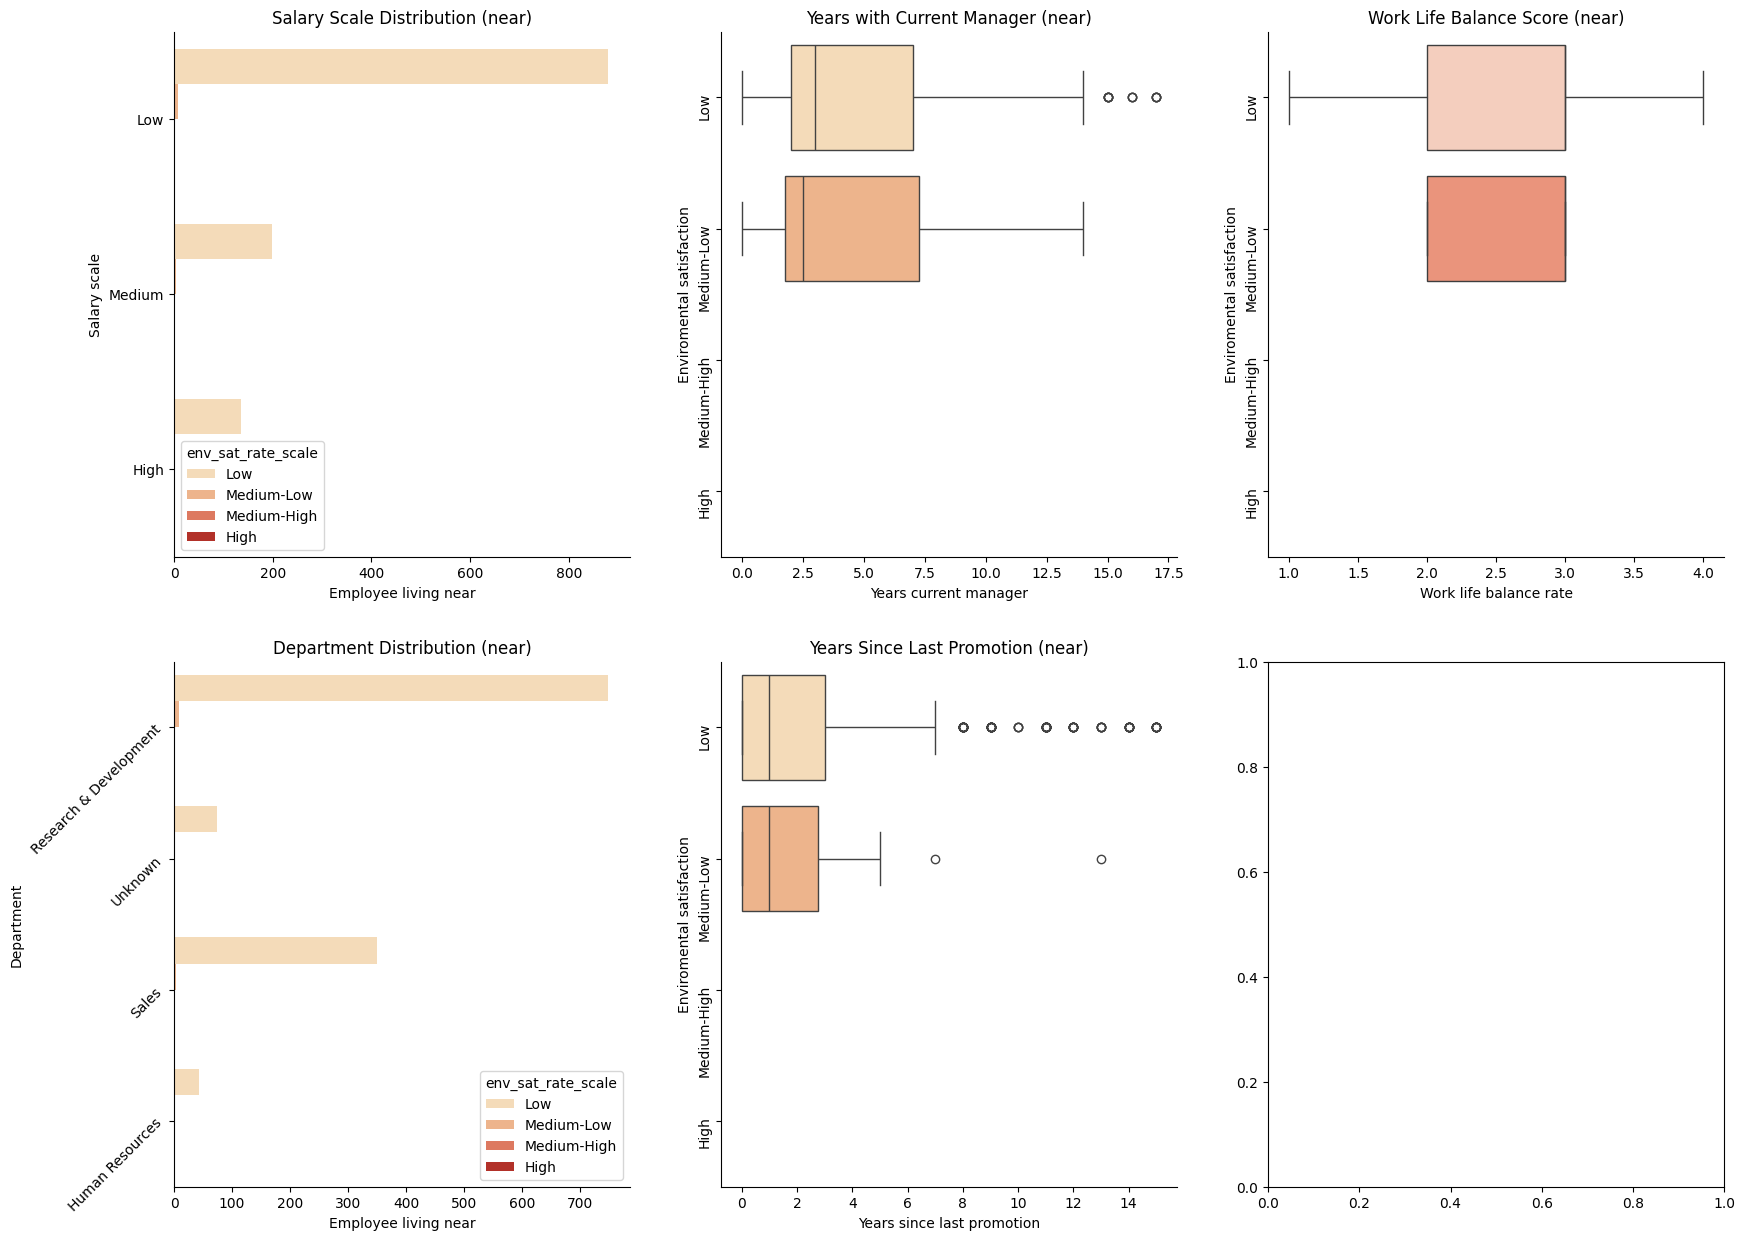

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(20, 15)) 

sns.countplot(data=near_df,
              y='salary_scale',
              hue='env_sat_rate_scale',
              ax=axes[0,0],
              palette='OrRd')
axes[0,0].set_title('Salary Scale Distribution (near)')
axes[0,0].set_xlabel('Employee living near')
axes[0,0].set_ylabel('Salary scale')
axes[0,0].spines['right'].set_visible(False)
axes[0,0].spines['top'].set_visible(False)


sns.countplot(data=near_df,
              y='department',
              hue='env_sat_rate_scale',
              ax=axes[1,0],
              palette='OrRd')
axes[1,0].set_title('Department Distribution (near)')
axes[1,0].tick_params(axis='y', rotation=45)
axes[1,0].set_xlabel('Employee living near')
axes[1,0].set_ylabel('Department')
axes[1,0].spines['right'].set_visible(False)
axes[1,0].spines['top'].set_visible(False)


sns.boxplot(data=near_df,
            x='year_current_mngr',
            ax=axes[0,1],
            y='env_sat_rate_scale',
            palette='OrRd')
axes[0,1].set_title('Years with Current Manager (near)')
axes[0,1].tick_params(axis='y', rotation=45)
axes[0,1].set_xlabel('Years current manager')
axes[0,1].set_ylabel('Enviromental satisfaction')
axes[0,1].tick_params(axis='y', rotation=90)
axes[0,1].spines['right'].set_visible(False)
axes[0,1].spines['top'].set_visible(False)


sns.boxplot(data=near_df, x='year_last_promotion',
            y='env_sat_rate_scale',
            ax=axes[1,1],
            palette='OrRd')
axes[1,1].set_title('Years Since Last Promotion (near)')
axes[1,1].tick_params(axis='y', rotation=90)
axes[1,1].set_ylabel('Enviromental satisfaction')
axes[1,1].set_xlabel('Years since last promotion')
axes[1,1].spines['right'].set_visible(False)
axes[1,1].spines['top'].set_visible(False)


sns.boxplot(data=near_df, x='work_life_balance',
            y='env_sat_rate_scale',
            ax=axes[0,2],
            palette='Reds')
axes[0,2].set_title('Work Life Balance Score (near)')
axes[0,2].set_ylabel('Enviromental satisfaction')
axes[0,2].tick_params(axis='y', rotation=90)
axes[0,2].set_xlabel('Work life balance rate')
axes[0,2].spines['right'].set_visible(False)
axes[0,2].spines['top'].set_visible(False)
plt.show();

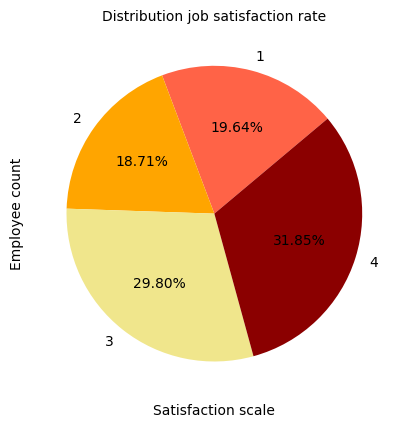

In [47]:
df_satisfaction_rate = df.groupby('job_sat_rate')['employee_number'].count().reset_index()

plt.pie('employee_number', labels = 'job_sat_rate', data=df_satisfaction_rate, autopct = '%1.2f%%', colors=['tomato', 'orange', 'khaki', 'darkred'], startangle=40, textprops={'fontsize': 10});

# Títulos y etiquetas
plt.title('Distribution job satisfaction rate', fontsize=10)
plt.xlabel('Satisfaction scale')
plt.ylabel('Employee count');

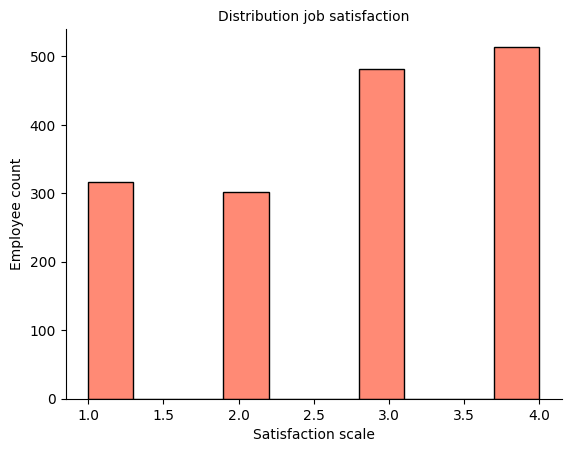

In [48]:
sns.histplot(data=df, x='job_sat_rate', bins=10, kde=False, color='tomato')
plt.title('Distribution job satisfaction', fontsize = 10)
plt.xlabel('Satisfaction scale')
plt.ylabel('Employee count');
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False);

Interpretación: La satisfacción en el puesto de trabajo en términos generales es positivo, ya que más de la mitad de los trabajadores marcan un nivel de satisfacción alto (60%), aunque el número de empleados con una satisfacción baja es bastante elevado (40%).

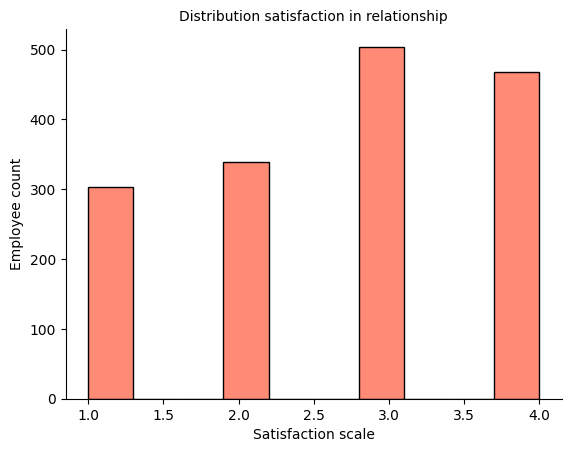

In [49]:
sns.histplot(data=df, x='relationship_sat_rate', bins=10, kde=False, color='tomato')
plt.title('Distribution satisfaction in relationship', fontsize = 10)
plt.xlabel('Satisfaction scale')
plt.ylabel('Employee count')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False);

Interpretación: Hay empleados en todos los niveles de satisfacción, aunque la curva muestra un aumento en los niveles más altos. Por lo que podemos concluir que la satisfacción general es positiva.

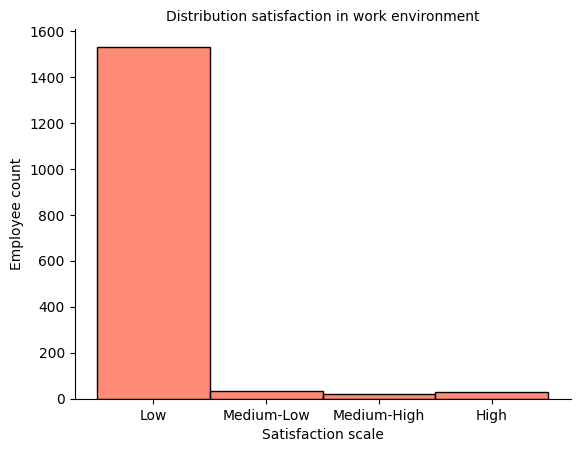

In [50]:
sns.histplot(data=df, x='env_sat_rate_scale', bins=10, kde=False, color='tomato')
plt.title('Distribution satisfaction in work environment', fontsize = 10)
plt.xlabel('Satisfaction scale')
plt.ylabel('Employee count')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False);

Interpretación: La mayoría de los empleados (más de 1400) reportan niveles muy bajos de satisfacción con su entorno laboral. La gráfica está fuertemente sesgada hacia la izquierda, con muy pocos empleados distribuidos en niveles medios y altos de satisfacción.

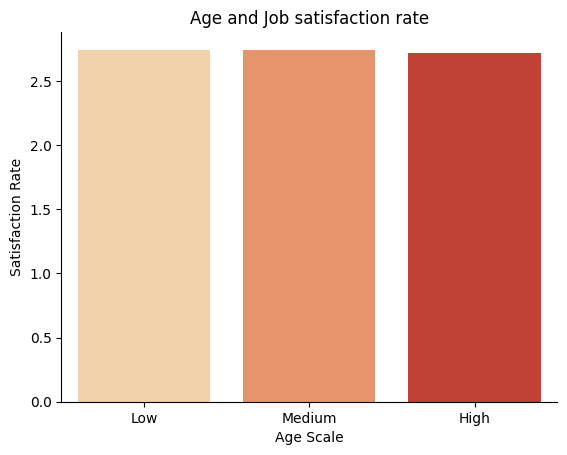

In [51]:
df['age_scale'] = pd.cut(df['age'],bins = 3, labels= ['Low', 'Medium', 'High'])
sns.barplot(data=df, y='job_sat_rate',
            x='age_scale',
            palette= 'OrRd',
            ci=False)
plt.title("Age and Job satisfaction rate")
plt.ylabel("Satisfaction Rate")
plt.xlabel("Age Scale")
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False);

Interpretación: no hay una relación entre la edad y la satisfacción.

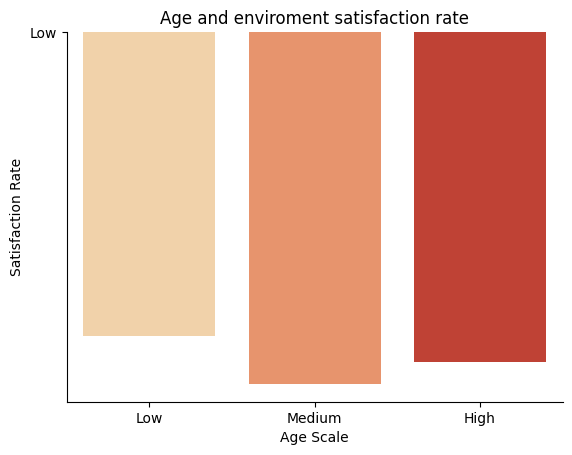

In [52]:
df['age_scale'] = pd.cut(df['age'],bins = 3, labels= ['Low', 'Medium', 'High'])
sns.barplot(data=df, y='env_sat_rate_scale',
            x='age_scale',
            palette= 'OrRd',
            ci=False)
plt.title("Age and enviroment satisfaction rate")
plt.ylabel("Satisfaction Rate")
plt.xlabel("Age Scale")
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False);

Interpretación: no hay una relación entre la edad y la satisfacción.

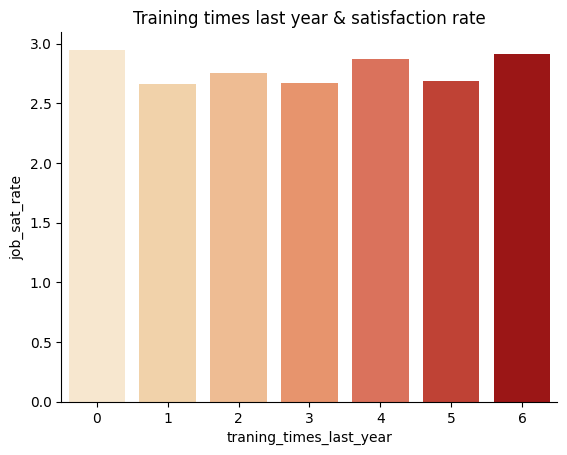

In [53]:
df['age_scale'] = pd.cut(df['age'],bins = 3, labels= ['Low', 'Medium', 'High'])
sns.barplot(data=df, y='job_sat_rate',
            x='traning_times_last_year',
            palette= 'OrRd',
            ci=False)
plt.title("Training times last year & satisfaction rate")
plt.ylabel("job_sat_rate")
plt.xlabel("traning_times_last_year")
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False);

Interpretación: no hay una relación entre el nivel educativo y la satisfacción.

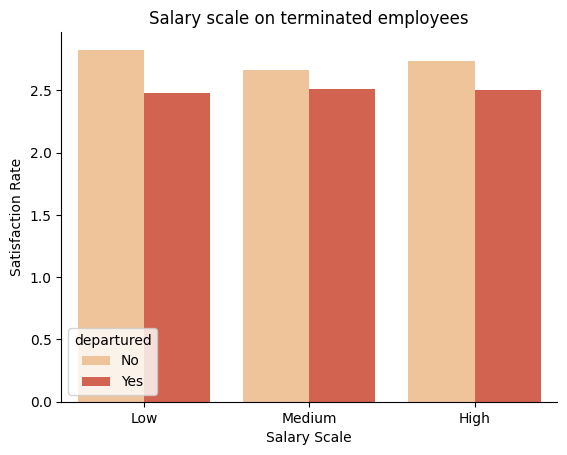

In [54]:
sns.barplot(data=df, y='job_sat_rate',
            x='salary_scale',
            hue='departured',
            palette= 'OrRd',
            ci=False)
plt.title("Salary scale on terminated employees")
plt.ylabel("Satisfaction Rate")
plt.xlabel("Salary Scale")
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False);

Interpretación: no hay una relación entre el rango salarial y la satisfacción, ni una diferencia significativa entre los han sido despedidos y los que continúan en la empresa.

In [55]:
df_count_departured = df.groupby('departured')['employee_number'].count().reset_index()

In [56]:
df['current_mngr'] = pd.cut(df['year_current_mngr'],bins = 4, labels= ['0-5', '6-10', '11-15', '16-20'])

In [57]:
yes_df = df[df['departured'] == 'Yes']
no_df = df[df['departured'] == 'No']

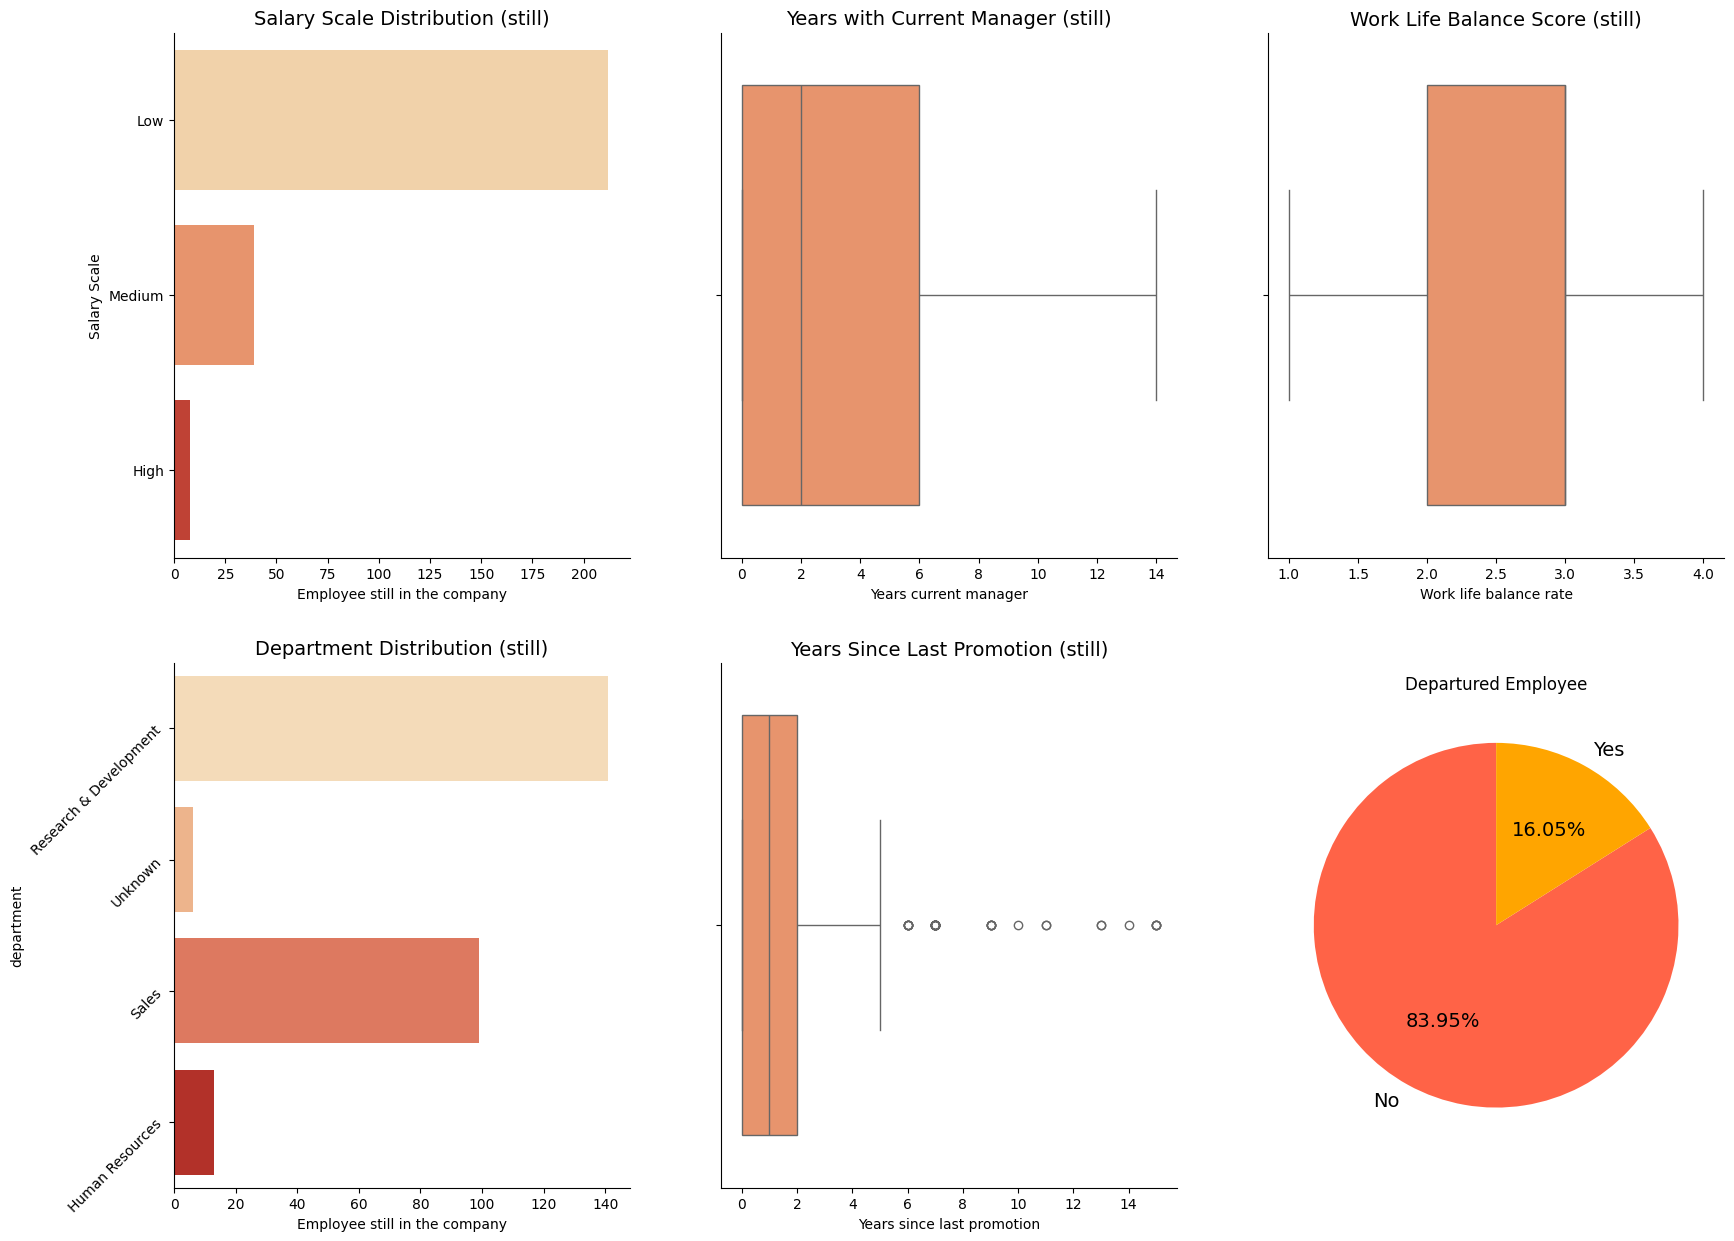

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(20, 15))

sns.countplot(data=yes_df,
              y='salary_scale',
              ax=axes[0, 0],
              palette='OrRd')
axes[0, 0].set_title('Salary Scale Distribution (still)', fontsize= 14)
axes[0, 0].set_xlabel('Employee still in the company')
axes[0, 0].set_ylabel('Salary Scale')
axes[0, 0].spines['right'].set_visible(False)
axes[0, 0].spines['top'].set_visible(False)


sns.countplot(data=yes_df,
              y='department',
              ax=axes[1, 0],
              palette='OrRd')
axes[1, 0].set_title('Department Distribution (still)', fontsize= 14)
axes[1, 0].tick_params(axis='y', rotation=45)
axes[1, 0].set_xlabel('Employee still in the company')
axes[1, 0].spines['right'].set_visible(False)
axes[1, 0].spines['top'].set_visible(False)


sns.boxplot(data=yes_df,
            x='year_current_mngr',
            ax=axes[0, 1],
            palette='OrRd'),
axes[0, 1].set_title('Years with Current Manager (still)', fontsize= 14)
axes[0, 1].tick_params(axis='y', rotation=45)
axes[0, 1].set_xlabel('Years current manager')
axes[0, 1].set_ylabel('')
axes[0, 1].tick_params(axis='y', rotation=90)
axes[0, 1].spines['right'].set_visible(False)
axes[0, 1].spines['top'].set_visible(False)


sns.boxplot(data=yes_df, x='year_last_promotion',
            ax=axes[1, 1],
            palette='OrRd'),
axes[1, 1].set_title('Years Since Last Promotion (still)', fontsize= 14)
axes[1, 1].tick_params(axis='y', rotation=90)
axes[1, 1].set_ylabel(' ')
axes[1, 1].set_xlabel('Years since last promotion')
axes[1, 1].spines['right'].set_visible(False)
axes[1, 1].spines['top'].set_visible(False)


sns.boxplot(data=yes_df, x='work_life_balance',
            ax=axes[0, 2],
            palette='OrRd'),
axes[0, 2].set_title('Work Life Balance Score (still)', fontsize= 14)
axes[0, 2].set_ylabel('')
axes[0, 2].tick_params(axis='y', rotation=90)
axes[0, 2].set_xlabel('Work life balance rate')
axes[0, 2].spines['right'].set_visible(False)
axes[0, 2].spines['top'].set_visible(False)


plt.pie('employee_number', labels = 'departured', data=df_count_departured, autopct = '%1.2f%%', 
        colors=['tomato', 'orange'], startangle=90, textprops={'fontsize': 14})
axes[1, 2].set_title('Departured Employee');




Interpretación: en esta gráfica observamos solo a los trabajadores que yano trabajan en la empresa. Los empleados con salarios bajos son los que dejan antes la empresa, seguidos por los del departamento de Research and Development. En general duran con su jefe una media de dos años aproximadamente y son promocionados aproximadamente cada año, a excepción de  algunos trabajadores. En general tienen una buena conciliación laboral.

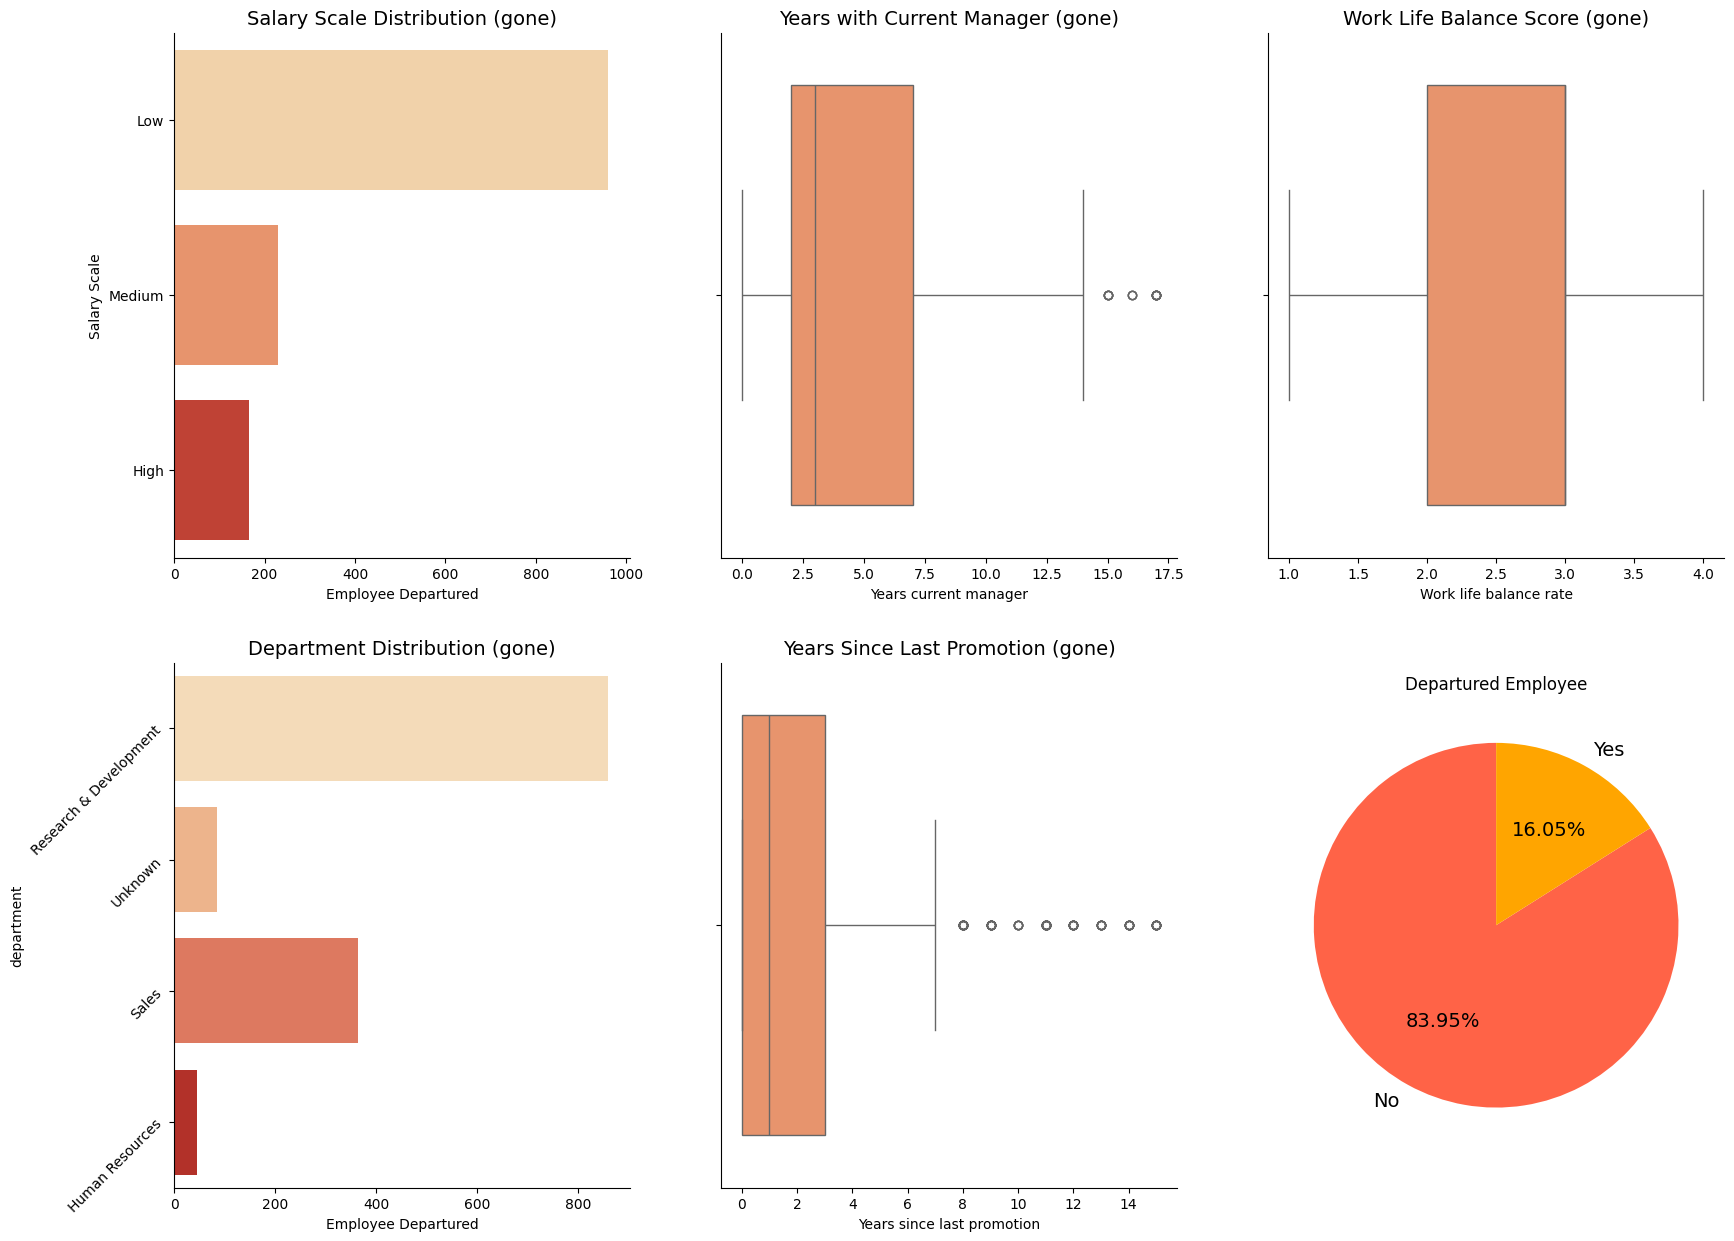

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(20, 15))

sns.countplot(data=no_df,
              y='salary_scale',
              ax=axes[0, 0],
              palette='OrRd')
axes[0, 0].set_title('Salary Scale Distribution (gone)', fontsize= 14)
axes[0, 0].set_xlabel('Employee Departured')
axes[0, 0].set_ylabel('Salary Scale')
axes[0, 0].spines['right'].set_visible(False)
axes[0, 0].spines['top'].set_visible(False)


sns.countplot(data=no_df,
              y='department',
              ax=axes[1, 0],
              palette='OrRd')
axes[1, 0].set_title('Department Distribution (gone)', fontsize= 14)
axes[1, 0].tick_params(axis='y', rotation=45)
axes[1, 0].set_xlabel('Employee Departured')
axes[1, 0].spines['right'].set_visible(False)
axes[1, 0].spines['top'].set_visible(False)


sns.boxplot(data=no_df,
            x='year_current_mngr',
            ax=axes[0, 1],
            palette='OrRd'),
axes[0, 1].set_title('Years with Current Manager (gone)', fontsize= 14)
axes[0, 1].tick_params(axis='y', rotation=45)
axes[0, 1].set_xlabel('Years current manager')
axes[0, 1].set_ylabel('')
axes[0, 1].tick_params(axis='y', rotation=90)
axes[0, 1].spines['right'].set_visible(False)
axes[0, 1].spines['top'].set_visible(False)


sns.boxplot(data=no_df, x='year_last_promotion',
            ax=axes[1, 1],
            palette='OrRd'),
axes[1, 1].set_title('Years Since Last Promotion (gone)', fontsize= 14)
axes[1, 1].tick_params(axis='y', rotation=90)
axes[1, 1].set_ylabel(' ')
axes[1, 1].set_xlabel('Years since last promotion')
axes[1, 1].spines['right'].set_visible(False)
axes[1, 1].spines['top'].set_visible(False)


sns.boxplot(data=no_df, x='work_life_balance',
            ax=axes[0, 2],
            palette='OrRd'),
axes[0, 2].set_title('Work Life Balance Score (gone)', fontsize= 14)
axes[0, 2].set_ylabel('')
axes[0, 2].tick_params(axis='y', rotation=90)
axes[0, 2].set_xlabel('Work life balance rate')
axes[0, 2].spines['right'].set_visible(False)
axes[0, 2].spines['top'].set_visible(False)


plt.pie('employee_number', labels = 'departured', data=df_count_departured, autopct = '%1.2f%%', 
        colors=['tomato', 'orange'], startangle=90, textprops={'fontsize': 14})
axes[1, 2].set_title('Departured Employee');




In [60]:
df.head(1)

,employee_number,gender,birth_year,age,marital_status,dist_home,job_title,department,departured,year_at_comp,standard_hours,remote,business_travel,over_time,job_level,stock_opt_level,traning_times_last_year,perf_rate,year_last_promotion,year_current_mngr,education_field,education_scale,annual_salary,monthly_income,daily_rate,perc_salary_hike,env_sat_rate,job_involvement,job_sat_rate,relationship_sat_rate,work_life_balance,num_comp_worked,tot_working_year,env_sat_rate_scale,env_sat_rate_scale_num,salary_scale,dist_home_scale,age_scale,current_mngr
0,1,M,1972,51.0,Unknown,6,Research Director,Research & Development,No,20,Full Time,Yes,Unknown,No,5,0,5,3.0,15,15,Unknown,3,195370.0,16280.83,2015.722222,13,1,3,3,3,3,7,NaN,Low,1,High,Near,High,16-20


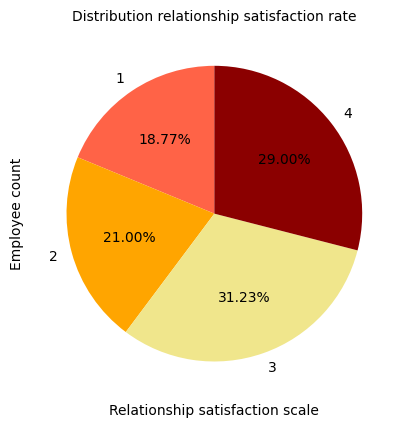

In [61]:
#distribution relationship satisfaction rate
df_relationship_sat_rate = df.groupby('relationship_sat_rate')['employee_number'].count().reset_index()

plt.pie('employee_number', labels = 'relationship_sat_rate', data=df_relationship_sat_rate, autopct = '%1.2f%%', colors=['tomato', 'orange', 'khaki', 'darkred'], startangle=90, textprops={'fontsize': 10});
# Títulos y etiquetas
plt.title('Distribution relationship satisfaction rate', fontsize=10)
plt.xlabel('Relationship satisfaction scale')
plt.ylabel('Employee count');

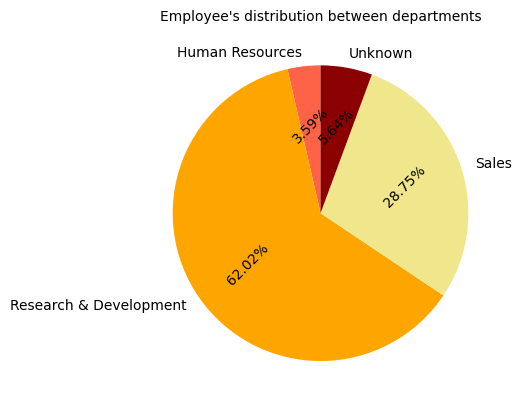

In [ ]:
#Distribución de los empleados en función de los departamentos:
df_deparment = df.groupby('department')['employee_number'].count().reset_index()

fig, ax = plt.subplots()

# Crear gráfico de pastel
wedges, texts, autotexts = ax.pie(
    df_deparment['employee_number'],
    labels=df_deparment['department'],
    autopct='%1.2f%%',
    colors=['tomato', 'orange', 'khaki', 'darkred'],
    startangle=90,
    textprops={'fontsize': 10}
)

# Rotar los porcentajes (autotexts)
for autotext in autotexts:
    autotext.set_rotation(45)  # Para cambiar el ángulo

# Título
ax.set_title("Employee's distribution between departments", fontsize=10);

In [63]:
df.columns

Index(['employee_number', 'gender', 'birth_year', 'age', 'marital_status',
       'dist_home', 'job_title', 'department', 'departured', 'year_at_comp',
       'standard_hours', 'remote', 'business_travel', 'over_time', 'job_level',
       'stock_opt_level', 'traning_times_last_year', 'perf_rate',
       'year_last_promotion', 'year_current_mngr', 'education_field',
       'education_scale', 'annual_salary', 'monthly_income', 'daily_rate',
       'perc_salary_hike', 'env_sat_rate', 'job_involvement', 'job_sat_rate',
       'relationship_sat_rate', 'work_life_balance', 'num_comp_worked',
       'tot_working_year', 'env_sat_rate_scale', 'env_sat_rate_scale_num',
       'salary_scale', 'dist_home_scale', 'age_scale', 'current_mngr'],
      dtype='object')

In [64]:
df['env_sat_rate_scale_num'].unique()

<IntegerArray>
[1, 4, 3, 2]
Length: 4, dtype: Int64

In [65]:
df['total_satisfaction'] = df['env_sat_rate_scale_num'] + df['relationship_sat_rate'] + df['job_sat_rate'] + df['job_involvement'] + df['work_life_balance']

In [66]:
df_sat_total_mean = df.groupby('department')['total_satisfaction'].mean().reset_index()

In [67]:
colors=['tomato', 'orange', 'khaki', 'darkred']

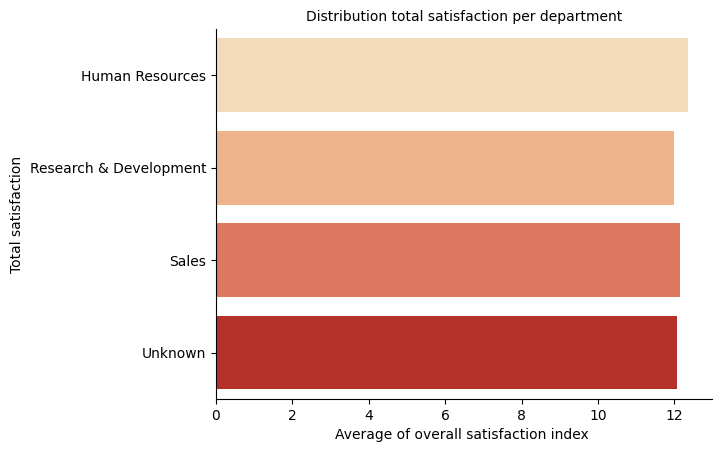

In [68]:
sns.barplot(data=df_sat_total_mean,
              y='department',
              x = 'total_satisfaction',
              palette='OrRd')

plt.title('Distribution total satisfaction per department', fontsize = 10)
plt.xlabel('Average of overall satisfaction index ')
plt.ylabel('Total satisfaction');
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

Interpretación:  no hay diferencia significativa en la distribución total de la satisfacción por departamento. Están todos los departamentos muy parejos.

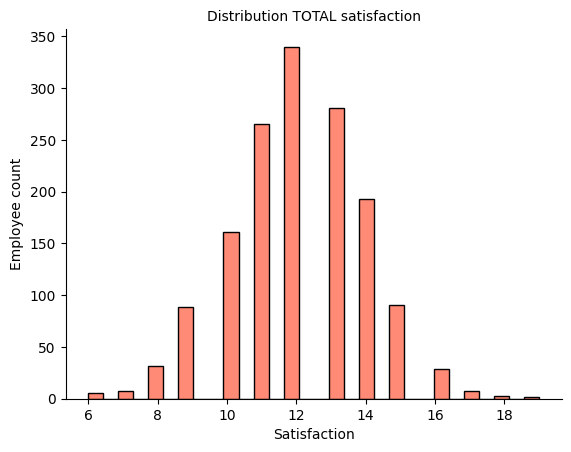

In [69]:
sns.histplot(data=df, x='total_satisfaction', bins=30, kde=False, color='tomato')
plt.title('Distribution TOTAL satisfaction', fontsize = 10)
plt.xlabel('Satisfaction')
plt.ylabel('Employee count')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False);

Interpretación: La puntuación es sobre 20. Se ve que sigue una distribución Normal por la forma en la que la satisfacción total está distribuida. 